In [1]:
import pandas as pd  # biblioteca com ferramentas para análise de dados/dataframes
import numpy as np  # biblioteca com operações matemáticas
import matplotlib.pyplot as plt # biblioteca para a geração de gráficos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# prompt: criar dataframe com o arquivo ANÁLISE MATRÍCULAS POR ANO - DADOS.csv

df = pd.read_csv("/content/drive/MyDrive/EMPRESAS/INSTITUTO REI SALOMAO/PROGRAMA DE INCENTIVO/dados_mat_21-25.csv")


In [ ]:
 df.head()

In [ ]:
# prompt: mostre apenas os nomes da colunas

print(df.columns.to_list())


['RU', 'Nome Aluno', 'Email', 'Telefone Residencial', 'Telefone Celular', 'Data Aniversário', 'Código da Região', 'Região', 'Código do Polo', 'Local', 'Código Nac', 'Nac', 'Origem da Inscrição', 'Turma', 'Turno', 'Nome Curso', 'Situacao Anterior', 'Motivo da Entrada', 'Situação Aluno', 'Carga HorariaGrade', 'Data Ocorrência', 'Nível', 'Modalidade', 'Opção Curso (Ingresso)', 'Data Matrícula', 'Data Contrato Assinado Aluno', 'Aditivo de Transferência', 'RU Responsável Legal', 'Contrato Assinado Responsável Legal', 'Data Contrato Assinado Responsável', 'resp Matricula', 'Perfil Resp Matricula', 'Trâmite', 'Documentos Pendentes', 'Situação Financeira', 'Plano Financeiro Ativo', 'Data Vencimento', 'ADD RU Amigo', 'Nome do Evento', 'Deficiência', 'UtilizadoVoucher', 'CursoOrigem', 'InscricaoOrigem']


In [ ]:
# prompt: crie um outro dataframe com as colunas 'RU', 'Nome Aluno', 'Email',  'Telefone Celular', 'Data Aniversário', 'Nome Curso', 'Situação Aluno', 'Data Ocorrência', 'Nível', 'Data Matrícula',  'resp Matricula'

novo_df = df[['RU', 'Nome Aluno', 'Email', 'Telefone Celular', 'Data Aniversário', 'Nome Curso', 'Situação Aluno', 'Data Ocorrência', 'Nível', 'Data Matrícula', 'resp Matricula']]
novo_df.head()


In [ ]:
# Gerar a média mensal de matrículas dos alunos

novo_df['Data Matrícula'] = pd.to_datetime(
    novo_df['Data Matrícula'],
    errors='coerce',
    dayfirst=True
)

df_periodo = novo_df[
    novo_df['Data Matrícula'].dt.year.between(2021, 2025)
]

df_periodo['Ano'] = df_periodo['Data Matrícula'].dt.year
df_periodo['Mes'] = df_periodo['Data Matrícula'].dt.month

matriculas_mes_ano = (
    df_periodo
    .groupby(['Ano', 'Mes'])
    .size()
    .reset_index(name='Qtd_Matriculas')
)

media_mensal = (
    matriculas_mes_ano
    .groupby('Mes')['Qtd_Matriculas']
    .mean()
    .reset_index(name='Media_Mensal')
)

/tmp/ipykernel_1781/3632968813.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  novo_df['Data Matrícula'] = pd.to_datetime(


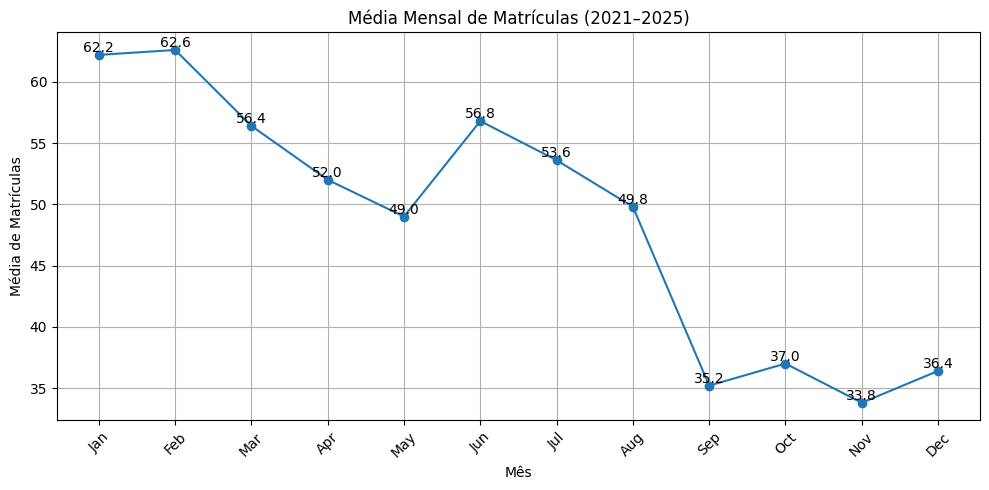

In [ ]:
import calendar
# GERAR GRÁFICO DE MÉDIA DE MATRÍCULAS POR ANO
plt.figure(figsize=(10, 5))

# Create 'Mes_nome' column in media_mensal
media_mensal['Mes_nome'] = media_mensal['Mes'].apply(lambda x: calendar.month_abbr[x])

plt.plot(
    media_mensal['Mes_nome'],
    media_mensal['Media_Mensal'],
    marker='o'
)

# Adicionar os valores em cada ponto
for x, y in zip(media_mensal['Mes_nome'], media_mensal['Media_Mensal']):
    plt.text(
        x, y,
        f'{y:.1f}',      # 1 casa decimal
        ha='center',
        va='bottom'
    )

plt.title('Média Mensal de Matrículas (2021–2025)')
plt.xlabel('Mês')
plt.ylabel('Média de Matrículas')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

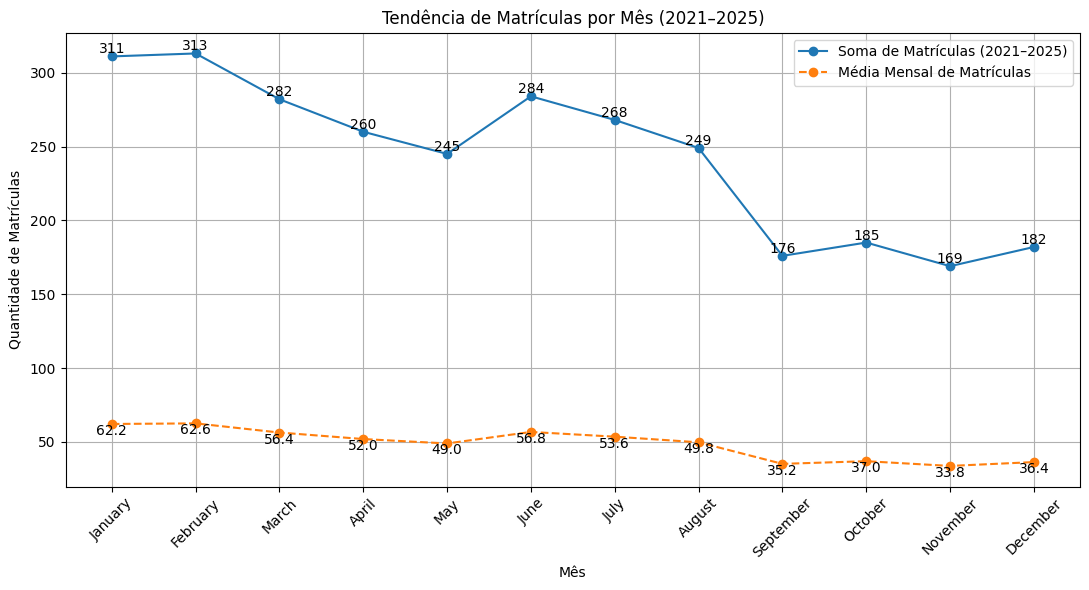

In [ ]:
# GERAR GRÁFICO DE TENDENCIA COM DUAS LINHAS - MÉDIA E SOMA MENSAL
soma_mensal = (
    matriculas_mes_ano
    .groupby('Mes')['Qtd_Matriculas']
    .sum()
    .reset_index(name='Soma_Mensal')
)

tendencia = pd.merge(
    soma_mensal,
    media_mensal,
    on='Mes'
).sort_values('Mes')

tendencia['Mes_nome'] = pd.to_datetime(
    tendencia['Mes'], format='%m'
).dt.month_name()

plt.figure(figsize=(11, 6))

# Linha da soma
plt.plot(
    tendencia['Mes_nome'],
    tendencia['Soma_Mensal'],
    marker='o',
    label='Soma de Matrículas (2021–2025)'
)

# Linha da média
plt.plot(
    tendencia['Mes_nome'],
    tendencia['Media_Mensal'],
    marker='o',
    linestyle='--',
    label='Média Mensal de Matrículas'
)

# Mostrar valores nos pontos (opcional)
for x, y in zip(tendencia['Mes_nome'], tendencia['Soma_Mensal']):
    plt.text(x, y, f'{int(y)}', ha='center', va='bottom')

for x, y in zip(tendencia['Mes_nome'], tendencia['Media_Mensal']):
    plt.text(x, y, f'{y:.1f}', ha='center', va='top')

plt.title('Tendência de Matrículas por Mês (2021–2025)')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Matrículas')

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


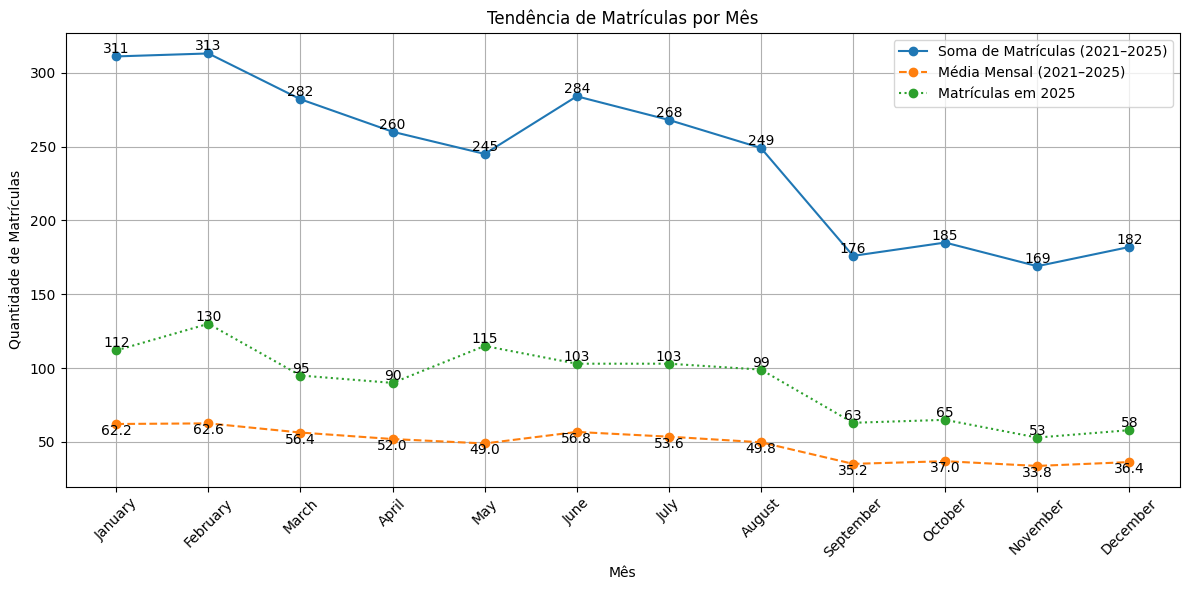

In [ ]:
# GERAR GRÁFICO COM 3 LINHAS - Média mensal dos últimos 5 anos, soma mensal dos últimos 5 anos e quantidade de matrículas ano anterior

matriculas_2025 = (
    df_periodo[df_periodo['Ano'] == 2025]
    .groupby('Mes')
    .size()
    .reset_index(name='Matriculas_2025')
)
tendencia = (
    soma_mensal
    .merge(media_mensal, on='Mes')
    .merge(matriculas_2025, on='Mes', how='left')
    .sort_values('Mes')
)
tendencia['Matriculas_2025'] = tendencia['Matriculas_2025'].fillna(0)
tendencia['Mes_nome'] = pd.to_datetime(
    tendencia['Mes'], format='%m'
).dt.month_name()

plt.figure(figsize=(12, 6))

# Linha 1: Soma (2021–2025)
plt.plot(
    tendencia['Mes_nome'],
    tendencia['Soma_Mensal'],
    marker='o',
    label='Soma de Matrículas (2021–2025)'
)

# Linha 2: Média
plt.plot(
    tendencia['Mes_nome'],
    tendencia['Media_Mensal'],
    marker='o',
    linestyle='--',
    label='Média Mensal (2021–2025)'
)

# Linha 3: Ano de 2025
plt.plot(
    tendencia['Mes_nome'],
    tendencia['Matriculas_2025'],
    marker='o',
    linestyle=':',
    label='Matrículas em 2025'
)

# Mostrar valores nos pontos
for x, y in zip(tendencia['Mes_nome'], tendencia['Matriculas_2025']):
    plt.text(x, y, f'{int(y)}', ha='center', va='bottom')

for x, y in zip(tendencia['Mes_nome'], tendencia['Soma_Mensal']):
    plt.text(x, y, f'{int(y)}', ha='center', va='bottom')

for x, y in zip(tendencia['Mes_nome'], tendencia['Media_Mensal']):
    plt.text(x, y, f'{y:.1f}', ha='center', va='top')

plt.title('Tendência de Matrículas por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Matrículas')

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
qtd_matricula_ano = pd.to_datetime(novo_df['Data Matrícula']).dt.year

matricula = novo_df.groupby(qtd_matricula_ano)['Data Matrícula'].count()

print(matricula)



Data Matrícula
2021     362
2022     342
2023     487
2024     647
2025    1086
Name: Data Matrícula, dtype: int64


In [ ]:
# prompt: conte a quantidade de resultados, baseado na data matrícula,  por ano e mês a partir de 2019 não incluindo 2024

#quantidade_por_ano_mes = novo_df[novo_df['Data Matricula_ano'] >= 2019]
#quantidade_por_ano_mes = quantidade_por_ano_mes[quantidade_por_ano_mes['Data Matricula_ano'] <= 2025]
ano = pd.to_datetime(novo_df['Data Matrícula']).dt.year
mes = pd.to_datetime(novo_df['Data Matrícula']).dt.month
quantidade_por_ano_mes = novo_df.groupby([ano, mes])['Data Matrícula'].count()

print(quantidade_por_ano_mes)

quantidade_por_ano_mes.to_csv('quantidade_MAT_por_ano_mes.csv')
files.download('quantidade_MAT_por_ano_mes.csv')


Data Matrícula  Data Matrícula
2021            1                  39
                2                  30
                3                  41
                4                  40
                5                  29
                6                  39
                7                  27
                8                  23
                9                  21
                10                 27
                11                 26
                12                 20
2022            1                  30
                2                  47
                3                  32
                4                  27
                5                  21
                6                  32
                7                  38
                8                  25
                9                  31
                10                 15
                11                 26
                12                 18
2023            1                  56
                2  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#MEDIA POR MES DOS ANOS DO ARQUIVO

ano = pd.to_datetime(novo_df['Data Matrícula']).dt.year
mes = pd.to_datetime(novo_df['Data Matrícula']).dt.month
quantidade_por_ano_mes = novo_df.groupby([ano, mes])['Data Matrícula'].count()
media = quantidade_por_ano_mes.groupby(level=1).mean()
media.columns = ['Mês', 'Média Valor']

print(media)

#print(quantidade_por_ano_mes)

Data Matrícula
1     62.2
2     62.6
3     56.4
4     52.0
5     49.0
6     56.8
7     53.6
8     49.8
9     35.2
10    37.0
11    33.8
12    36.4
Name: Data Matrícula, dtype: float64


In [ ]:
#SABER QUANTOS ALUNOS FIZERAM A MATRÍCULA EM 2024 E CANCELARAM

mat2024 = novo_df[pd.to_datetime(novo_df['Data Matrícula']).dt.year == 2025]
can2024 = mat2024[mat2024['Situação Aluno'] == 'CANCELADO'].count() + mat2024[mat2024['Situação Aluno'] == 'CANCELADO - DOC'].count() + mat2024[mat2024['Situação Aluno'] == 'ABANDONO PRESCRIÇÃO'].count() + mat2024[mat2024['Situação Aluno'] == 'CANCELADO PENDÊNCIA DOC'].count() + mat2024[mat2024['Situação Aluno'] == 'ABANDONO CONFIRMAÇÃO'].count() + mat2024[mat2024['Situação Aluno'] == 'ABANDONO CONFIRMAÇÃO – CONDICIONAL DOC'].count()

print(can2024)


RU                  281
Nome Aluno          281
Email               271
Telefone Celular    258
Data Aniversário    281
Nome Curso          281
Situação Aluno      281
Data Ocorrência     281
Nível               281
Data Matrícula      281
resp Matricula      281
dtype: int64


In [ ]:
# Substituir os valores na coluna 'Situação Aluno'
novo_df['Situação Aluno'] = novo_df['Situação Aluno'].replace('CANCELADO PENDÊNCIA DOC', 'CANCELADO')

/tmp/ipython-input-986371297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  novo_df['Situação Aluno'] = novo_df['Situação Aluno'].replace('CANCELADO PENDÊNCIA DOC', 'CANCELADO')


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [ ]:
ano_ = pd.to_datetime(novo_df['Data Matrícula'], format='%d/%m/%Y %H:%M:%S')
ano_ = ano_.dt.year
r = novo_df.query("2017 < @ano_ < 2024")
s = r['RU'].value_counts()

print(s)

RU
424985     5
563556     5
3673689    4
685378     4
4364329    4
516403     4
329214     4
4159484    4
3744802    4
753719     3
4554094    3
3640852    3
528042     3
4259483    3
4157265    3
3747053    3
3622145    3
4159452    3
3726701    3
427482     3
642544     3
4651923    2
1782464    2
4637804    2
4626279    2
4588493    2
660682     2
4586850    2
4392257    2
603108     2
4385591    2
4409400    2
4440881    2
2791224    2
3595159    2
3062860    2
3672671    2
4308924    2
1149813    2
2403353    2
762851     2
4306505    2
4515540    2
4518888    2
4232326    2
4223673    2
4254769    2
4177302    2
759888     2
4457304    2
3654564    2
2094331    2
4548236    2
4172031    2
826756     2
4519297    2
363543     2
4673576    2
361368     2
4620953    2
3959311    2
4328850    2
4321088    2
171660     2
4332139    2
4066010    2
3963111    2
4348010    2
1820678    2
4385585    2
4378762    2
4271959    2
3957386    2
2866765    2
485946     2
147821     2
3675820  